In [ ]:
import json
from pathlib import Path
import marimo as mo
try:
    case_dir = Path(__file__).resolve().parent
except NameError:  # Jupyter does not define __file__.
    case_dir = next(
        location / "examples" / "scverse-anndata"
        for location in (Path.cwd(), *Path.cwd().parents)
        if (location / "examples" / "scverse-anndata" / "case.json").exists()
    )
case = json.loads((case_dir / "case.json").read_text())

In [ ]:
mo.md(f"# {case['title']}\n\nStatus: **{case['status']}**")

# AnnData: dense H5AD to CSR/CSC

Status: **replayed**

In [ ]:
mo.md((case_dir / "walkthrough.md").read_text())

## Request

> Make AnnData's dense H5AD-to-CSR/CSC conversion faster. Preserve exact sparse outputs. Allow Python and native C changes on the pinned CPU, with one-core execution and bounded memory. Propose the contract before preparing the evaluator.

## Setup

Six 7000 × 7000 float32 workloads cover CSR/CSC and three density/compression combinations. The reference is the copied pre-autoresearch implementation; the Phase 2 incumbent already includes Python/HDF5 improvements. The [contract](CONTRACT.md) and [handover](HANDOVER.md) give the full setup.

The score is the geometric mean of per-case medians of paired latency ratios. Exact CSR/CSC arrays, unchanged upstream tests, a 1536 MB RSS ceiling and a contracted 240-second timeout gate scoring. One CPU core, warm page cache, fixture data, dependencies, evaluator and build flags are frozen. Only the Python I/O module and optional native conversion file can change.

## Change

The initial notes identify dense slabs, intermediate SciPy sparse objects and a final stack/copy as possible overhead. The search can test chunk/layout-aware traversal, direct sparse construction and bounded allocation before or alongside available ISA features. A scalar C correctness port is a distinct hypothesis from SIMD acceleration; both must pass the same complete score.

## Evaluation

The external controller started a fresh worker for one experiment. It read the contract, handover, notes, recent ledger and source history, checked STOP, committed one in-scope candidate and called the single scorer shown in HANDOVER. The scorer rebuilt native code, tested outputs, measured paired timings and recorded the attempt. The worker then kept or restored source and wrote its interpretation before exiting.

Phase 2 calibration scores: 0.861417, 0.858227 and 0.870895. KEEP required an improvement over best prior greater than 0.02 ratio points.

## Result

The paired replay gives **2.151×** from 36 paired observations, with peak RSS **569.734 MB**. The measured boundary is conversion from open HDF5 objects, not remote `read_h5ad`.

The Validation report reports 19 passing upstream conversion tests and exact sparse checks. It also found that the source had been restored despite missing the KEEP margin. The replay validates the comparison, not that retention decision.

## Follow-up

Resolve the historical retention exception before calling the replayed source a rule-compliant winner. Portable deployment also needs fallback/dispatch tests and measurements on other CPUs.

In [ ]:
mo.md(
    "## Contract and handover\n\n"
    + (case_dir / "CONTRACT.md").read_text()
    + "\n\n---\n\n"
    + (case_dir / "HANDOVER.md").read_text()
)

## Contract and handover

# AnnData native conversion: historical contract extract

Extract from the Phase 2 machine-specific conversion contract.
The evaluator, candidate and environment bundle are incomplete; see
[evidence availability](../../RECOVERY.md).

## Objective

Minimise `relative_geomean`: the geometric mean across six workloads of the median
paired candidate/reference latency ratio. `1.0` means parity with the frozen
pre-autoresearch AnnData reference. Peak RSS and per-case ratios were also recorded.
Peak RSS was a hard gate; it was not a second optimisation objective.

## Editable and frozen surfaces

Editable: `src/anndata/_io/h5ad.py` and optional
`src/anndata/_io/_dense_sparse_native.c`. One hypothesis could change both.

Frozen: contract, fixture generation, evaluator, build command, scorer,
upstream conversion tests, data and copied reference. Dependencies could not change.
No benchmark-specific branches, converted-result caches or additional workers.

Native C, compiler vectorisation, intrinsics, inline assembly, cache/layout changes
and exact-output representation changes were allowed. Instructions had to be exposed
by the actual CPU. This was a machine-specific PoC; portable wheels and runtime
dispatch were explicitly outside its acceptance gates.

## Correctness and resource gates

- Build the optional native module with the frozen command.
- Pass unchanged `tests/test_io_conversion.py`.
- Match reference CSR/CSC type, shape, dtype, `indptr`, `indices` and `data` exactly.
- Peak RSS at most 1536 MB, including dense buffers, sparse output and native allocations.
- Contracted build/test/evaluation timeout: 240 seconds.
- No eager whole-file or persistent converted-output cache, benchmark detection or hidden threads.

## Measurement

- Deterministic 7000 × 7000 float32 HDF5 datasets.
- Three density/compression combinations: 0.1% uncompressed, 1% LZF, 10% gzip level 1.
- CSR and CSC for each: six workloads; `axis_chunk=6000`.
- One untimed warm-up, six paired candidate/reference observations per case.
- Deterministically randomised case order; alternating implementation order.
- Warm page cache; conversion from an open HDF5 object, not a remote whole-file read.
- CPU affinity to one core; common BLAS/OpenMP thread counts set to one.
- AMD EPYC 7B12 VM; GCC 11.4.0, CPython 3.13 environment at calibration.
- Frozen native flags: `-O3 -march=native -funroll-loops -fPIC -shared -std=c11`.

AVX2 was exposed; AVX-512 was not. The scope also allowed available non-SIMD features
and cache-aware changes. Changing CPU exposure, compiler, dependencies, fixtures,
evaluation or contention required recalibration.

## Calibration and retention

Phase 2 started from the retained Python/HDF5 implementation, not the original
unoptimised reference. Three initial scores were `0.861417`, `0.858227`, `0.870895`.
Their range was 1.47% of the median, below the 5% launch gate.

KEEP required all gates and `best_prior - candidate > 0.02` ratio points.
That is not a universal 2% relative-time threshold. Otherwise restore the incumbent
implementation and preserve the attempted candidate's record.

The later audit found that a measured passing candidate had been restored despite
missing that keep margin. The paired replay therefore records a measured
comparison, not compliance with the historical retention rule.


---

# AnnData: historical handover extract

Extract from the Phase 2 handover. Commands refer to the original prepared AnnData
worktree; its scorer is not included in this example folder.

- Contract: native conversion Phase 2; see the adjacent historical CONTRACT extract.
- Objective: minimise paired-ratio `relative_geomean` against the fixed original reference.
- Starting implementation: retained Phase 1 HDF5-row-aligned CSC traversal.
- Initial median score: `0.861417`; maximum observed calibration RSS: `569.141 MB`.
- KEEP: all gates pass and improvement over best prior exceeds `0.02` ratio points.
- Limits: 1536 MB peak RSS; contracted 240-second build/test/evaluation timeout.
- Mutable files: `src/anndata/_io/h5ad.py`, optional `_dense_sparse_native.c`.
- Frozen: contract, build, evaluator, upstream conversion tests, fixtures and scorer.
- Durable records: `autoresearch/results.tsv`, `autoresearch/thesis.md`, committed source.
- Stop signal: `autoresearch/STOP`.
- Execution: an external controller launched fresh workers; each did one experiment and exited.

Scorer command in the prepared worktree:

```sh
.venv/bin/python autoresearch/run.py -m "one change and its hypothesis"
```

It rebuilt the native module, ran upstream tests and then the paired evaluator. It
wrote the attempt record; the worker read the result and restored source on rejection.
It did not launch the coding agent itself.

The initial native backlog was to profile phase costs, establish a correct scalar C
implementation, inspect CPU/compiler/cache capabilities, then compare traversal,
allocation, scalar and instruction-level approaches using the full contracted score.

For a new campaign, generate a handover with your own reference, calibration,
paths, state reconciliation and limits.

In [ ]:
_path = case_dir / "evidence" / "replay.json"
if _path.exists():
    import statistics
    import math
    _record = json.loads(_path.read_text())
    _rows = []
    for _name, _samples in _record['result']['absolute_samples_ms'].items():
        _base = statistics.median(s['reference_ms'] for s in _samples)
        _candidate = statistics.median(s['candidate_ms'] for s in _samples)
        _rows.append({'case': _name, 'reference_ms': _base, 'candidate_ms': _candidate, 'speedup': _base / _candidate})
    _score = 1 / _record['result']['relative_geomean']
    _table = "| Case | Reference (ms) | Candidate (ms) | Ratio of medians |\n| --- | ---: | ---: | ---: |\n"
    _table += "\n".join(
        f"| {row['case']} | {row['reference_ms']:.2f} | {row['candidate_ms']:.2f} | {row['speedup']:.3f}× |"
        for row in _rows
    )
    _view = mo.md(
        f"## Recorded replay\n\nGeometric mean speedup: **{_score:.3f}×**. "
        "The table shows latency medians of six samples per implementation per case. "
        "The aggregate score instead uses per-case medians of paired latency ratios.\n\n"
        + _table
    )
else:
    _view = mo.md("")
_view

## Recorded replay

Geometric mean speedup: **2.151×**. The table shows latency medians of six samples per implementation per case. The aggregate score instead uses per-case medians of paired latency ratios.

| Case | Reference (ms) | Candidate (ms) | Ratio of medians |
| --- | ---: | ---: | ---: |
| f32_d0001_raw:csc | 346.01 | 104.57 | 3.309× |
| f32_d0001_raw:csr | 297.22 | 103.68 | 2.867× |
| f32_d001_lzf:csc | 1079.45 | 478.57 | 2.256× |
| f32_d001_lzf:csr | 672.93 | 468.78 | 1.435× |
| f32_d010_gzip1:csc | 1185.65 | 563.40 | 2.104× |
| f32_d010_gzip1:csr | 783.04 | 516.99 | 1.515× |

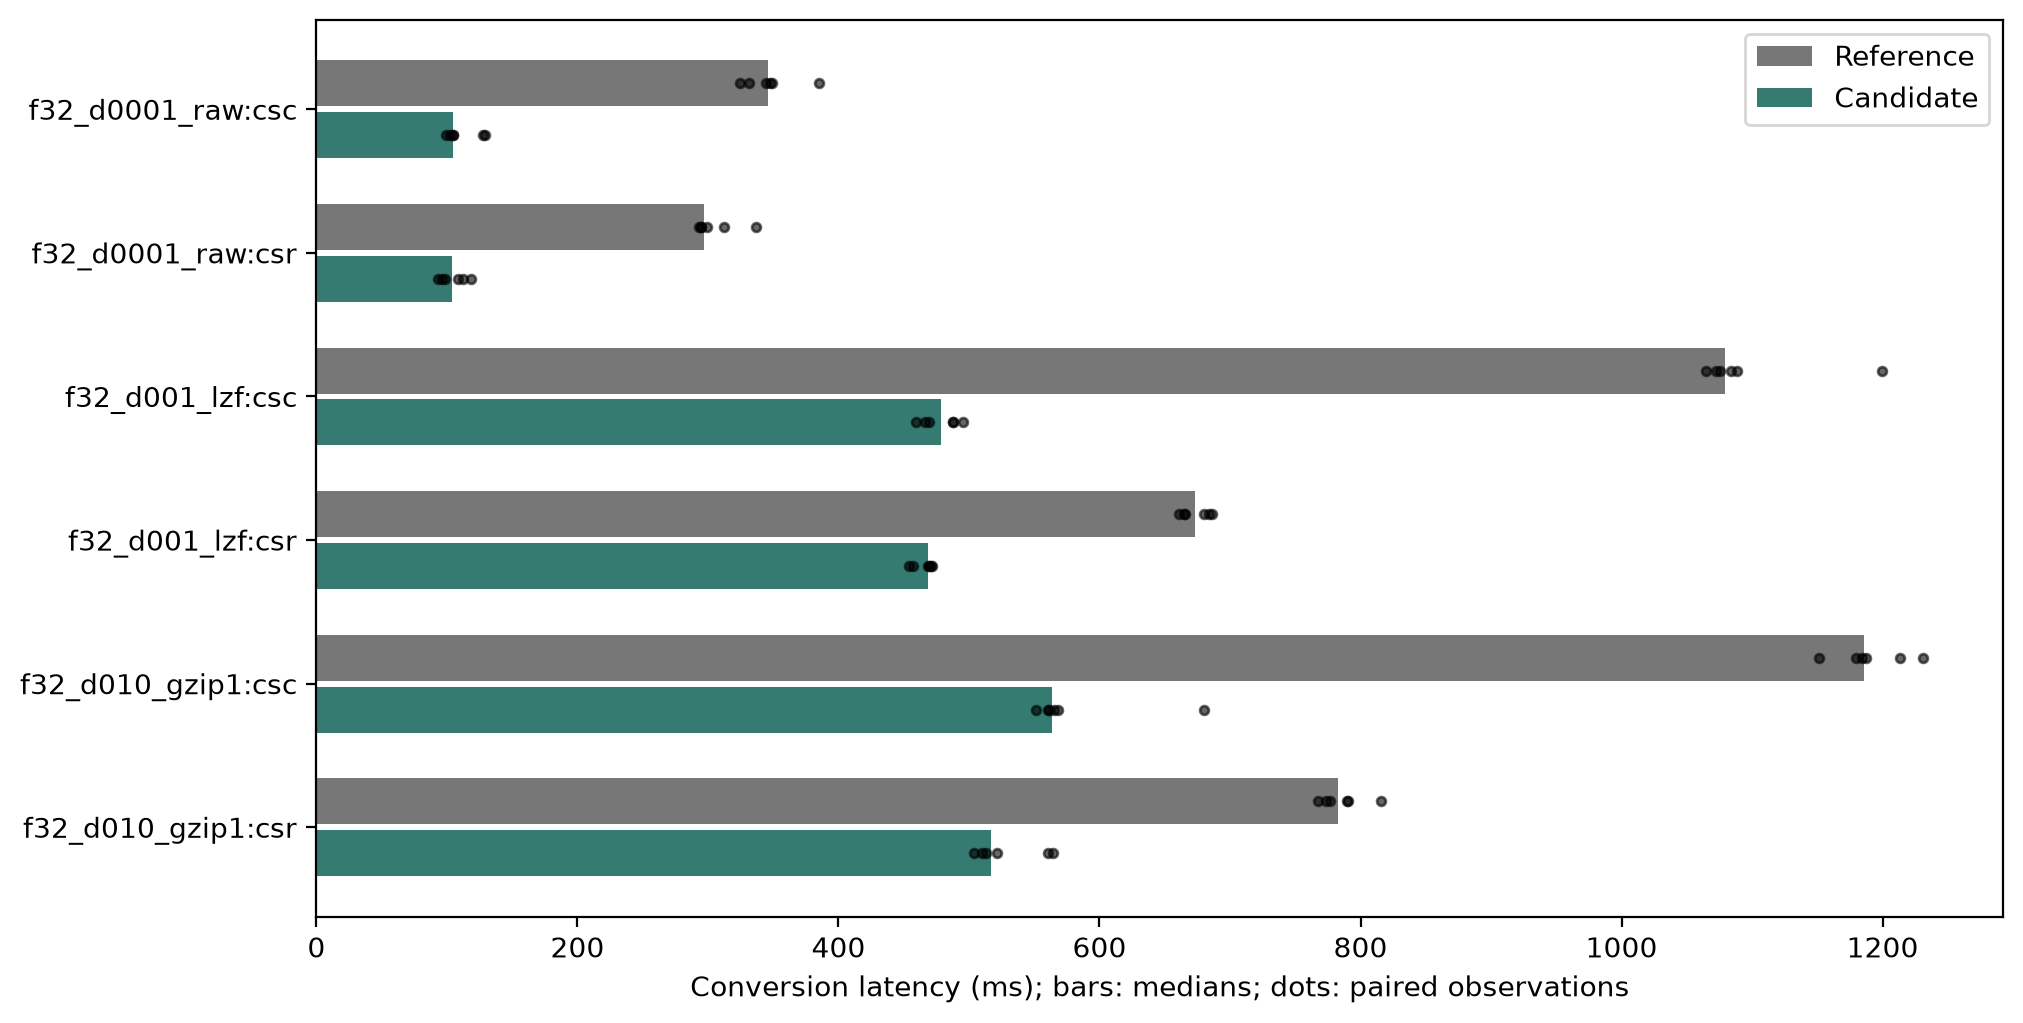

In [ ]:
from statistics import median
import matplotlib.pyplot as plt
_samples = json.loads(
    (case_dir / "evidence/replay.json").read_text()
)["result"]["absolute_samples_ms"]
_fig, _ax = plt.subplots(figsize=(10, 5), layout="constrained")
for _i, (_name, _pairs) in enumerate(_samples.items()):
    for _offset, _field, _label, _colour in (
        (-.18, "reference_ms", "Reference", "#777777"),
        (.18, "candidate_ms", "Candidate", "#357b71"),
    ):
        _values = [pair[_field] for pair in _pairs]
        _ax.barh(_i + _offset, median(_values), height=.32, color=_colour,
                 label=_label if _i == 0 else None)
        _ax.scatter(_values, [_i + _offset] * len(_values), color="black",
                    s=10, alpha=.6, zorder=3)
_ax.set_yticks(range(len(_samples)), list(_samples))
_ax.set_xlabel("Conversion latency (ms); bars: medians; dots: paired observations")
_ax.invert_yaxis()
_ax.legend()
_fig

In [ ]:
_audit = case_dir / "evidence" / "validation.md"
_links = "[Evidence record](evidence/provenance.json)"
if _audit.exists():
    _links += " · [Validation report](evidence/validation.md)"
mo.md("## Evidence\n\n" + _links)

## Evidence

[Evidence record](evidence/provenance.json) · [Validation report](evidence/validation.md)